# 01_cleaning.ipynb  
## Google Research – Web Traffic Time Series Forecasting  
### Data Loading, Cleaning, Sampling, Preprocessing

This notebook performs the initial steps of the pipeline:

- Load the raw Kaggle dataset  
- Understand the structure  
- Handle missing values  
- Apply log-transform  
- Randomly sample a subset of pages for modeling  
- Visualize a few time series  
- Save cleaned data for the next notebook  

This dataset contains daily Wikipedia page views for ~145,000 pages from 2015–2016.
Our goal is to forecast the next 60 days of views.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 50)


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the Kaggle Dataset

The dataset contains:
- A `train_1.csv` file with page titles as rows and dates as columns  
- Daily page views for each article  


### Load the file using the full path

In [3]:
file_path = "/content/drive/MyDrive/CSC480/Final Project/train_1.csv"

df = pd.read_csv(file_path)
df.head()


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,...,2016-12-17,2016-12-18,2016-12-19,2016-12-20,2016-12-21,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,24.0,19.0,10.0,14.0,15.0,...,21.0,21.0,47.0,65.0,17.0,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,4.0,41.0,65.0,57.0,38.0,...,17.0,15.0,22.0,23.0,19.0,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,4.0,1.0,1.0,1.0,6.0,...,6.0,2.0,2.0,4.0,3.0,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,16.0,16.0,11.0,23.0,145.0,...,18.0,13.0,18.0,23.0,10.0,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,15.0,4.0,11.0,7.0,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


## Understanding the Dataset Structure

- Each row = one Wikipedia page  
- First column: `Page`  
- Remaining columns: dates  
- Values: number of page views  


In [4]:
print("Shape:", df.shape)
df.info()


Shape: (145063, 551)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


## Extract Metadata (Language, Access Type, Agent Type)

Each page name in the dataset contains embedded metadata such as:

- Language (e.g., en, de, fr, zh)
- Access type (desktop, mobile, all-access)
- Agent type (user or spider)

We will extract these fields into separate columns for use in modeling.



In [5]:
def extract_language(page):
    try:
        return page.split(".")[0]
    except:
        return "unknown"

def extract_access(page):
    if "desktop" in page:
        return "desktop"
    elif "mobile" in page:
        return "mobile"
    else:
        return "unknown"

def extract_agent(page):
    if "spider" in page:
        return "spider"
    else:
        return "user"

df["language"] = df["Page"].apply(extract_language)
df["access"] = df["Page"].apply(extract_access)
df["agent"] = df["Page"].apply(extract_agent)

df[["Page", "language", "access", "agent"]].head()


,Page,language,access,agent
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1_zh,unknown,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM_zh,unknown,spider
2,3C_zh.wikipedia.org_all-access_spider,3C_zh,unknown,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute_zh,unknown,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You_zh,unknown,spider


## Random Sampling

The full dataset (145k pages × 550 days) is too large for fast modeling.

We randomly sample **500 pages** which is enough for good training results.


In [6]:
SAMPLE_SIZE = 500
df_sample = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

df_sample.head()


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,...,2016-12-20,2016-12-21,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,language,access,agent
0,Phabricator/Project_management_www.mediawiki.o...,6.0,6.0,4.0,6.0,8.0,6.0,4.0,0.0,2.0,3.0,2.0,3.0,3.0,7.0,...,9.0,23.0,6.0,6.0,11.0,4.0,6.0,5.0,7.0,6.0,6.0,9.0,Phabricator/Project_management_www,unknown,spider
1,Now_You_See_Me_es.wikipedia.org_desktop_all-ag...,242.0,271.0,309.0,227.0,321.0,311.0,242.0,236.0,243.0,266.0,381.0,347.0,336.0,344.0,...,305.0,257.0,231.0,222.0,193.0,229.0,334.0,316.0,324.0,268.0,201.0,190.0,Now_You_See_Me_es,desktop,user
2,Zürich_Hackathon_2014_www.mediawiki.org_all-ac...,3.0,19.0,19.0,30.0,21.0,24.0,17.0,178.0,40.0,1.0,3.0,2.0,4.0,11.0,...,5.0,10.0,6.0,7.0,4.0,8.0,2.0,4.0,9.0,4.0,11.0,12.0,Zürich_Hackathon_2014_www,unknown,spider
3,Érythrée_fr.wikipedia.org_desktop_all-agents,672.0,513.0,774.0,1164.0,546.0,755.0,555.0,494.0,4801.0,4514.0,1101.0,1113.0,747.0,923.0,...,374.0,282.0,308.0,294.0,358.0,204.0,323.0,438.0,345.0,299.0,306.0,211.0,Érythrée_fr,desktop,user
4,Metallica_es.wikipedia.org_all-access_all-agents,1534.0,1644.0,1704.0,1569.0,1534.0,1577.0,1608.0,1731.0,1919.0,1628.0,1640.0,1646.0,1635.0,1690.0,...,2333.0,2307.0,2367.0,2259.0,2229.0,2070.0,2774.0,2552.0,2524.0,2358.0,2291.0,2153.0,Metallica_es,unknown,user


## Handling Missing Values

We fill missing entries using:
- Linear interpolation across days  
- Fill remaining NAs with 0  


In [7]:
date_cols = df.columns[1:-3]  # all date columns
df_sample[date_cols] = df_sample[date_cols].interpolate(axis=1)
df_sample[date_cols] = df_sample[date_cols].fillna(0)

df_sample.head()


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,...,2016-12-20,2016-12-21,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,language,access,agent
0,Phabricator/Project_management_www.mediawiki.o...,6.0,6.0,4.0,6.0,8.0,6.0,4.0,0.0,2.0,3.0,2.0,3.0,3.0,7.0,...,9.0,23.0,6.0,6.0,11.0,4.0,6.0,5.0,7.0,6.0,6.0,9.0,Phabricator/Project_management_www,unknown,spider
1,Now_You_See_Me_es.wikipedia.org_desktop_all-ag...,242.0,271.0,309.0,227.0,321.0,311.0,242.0,236.0,243.0,266.0,381.0,347.0,336.0,344.0,...,305.0,257.0,231.0,222.0,193.0,229.0,334.0,316.0,324.0,268.0,201.0,190.0,Now_You_See_Me_es,desktop,user
2,Zürich_Hackathon_2014_www.mediawiki.org_all-ac...,3.0,19.0,19.0,30.0,21.0,24.0,17.0,178.0,40.0,1.0,3.0,2.0,4.0,11.0,...,5.0,10.0,6.0,7.0,4.0,8.0,2.0,4.0,9.0,4.0,11.0,12.0,Zürich_Hackathon_2014_www,unknown,spider
3,Érythrée_fr.wikipedia.org_desktop_all-agents,672.0,513.0,774.0,1164.0,546.0,755.0,555.0,494.0,4801.0,4514.0,1101.0,1113.0,747.0,923.0,...,374.0,282.0,308.0,294.0,358.0,204.0,323.0,438.0,345.0,299.0,306.0,211.0,Érythrée_fr,desktop,user
4,Metallica_es.wikipedia.org_all-access_all-agents,1534.0,1644.0,1704.0,1569.0,1534.0,1577.0,1608.0,1731.0,1919.0,1628.0,1640.0,1646.0,1635.0,1690.0,...,2333.0,2307.0,2367.0,2259.0,2229.0,2070.0,2774.0,2552.0,2524.0,2358.0,2291.0,2153.0,Metallica_es,unknown,user


## Log(1 + x) Transform

Page views vary wildly (0 → millions).  
A log-transform stabilizes variance and improves ML model performance.


In [8]:
df_log = df_sample.copy()
df_log[date_cols] = np.log1p(df_log[date_cols])
df_log.head()


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,...,2016-12-20,2016-12-21,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,language,access,agent
0,Phabricator/Project_management_www.mediawiki.o...,1.945910,1.945910,1.609438,1.945910,2.197225,1.945910,1.609438,0.000000,1.098612,1.386294,1.098612,1.386294,1.386294,2.079442,...,2.302585,3.178054,1.945910,1.945910,2.484907,1.609438,1.945910,1.791759,2.079442,1.945910,1.945910,2.302585,Phabricator/Project_management_www,unknown,spider
1,Now_You_See_Me_es.wikipedia.org_desktop_all-ag...,5.493061,5.605802,5.736572,5.429346,5.774552,5.743003,5.493061,5.468060,5.497168,5.587249,5.945421,5.852202,5.820083,5.843544,...,5.723585,5.552960,5.446737,5.407172,5.267858,5.438079,5.814131,5.758902,5.783825,5.594711,5.308268,5.252273,Now_You_See_Me_es,desktop,user
2,Zürich_Hackathon_2014_www.mediawiki.org_all-ac...,1.386294,2.995732,2.995732,3.433987,3.091042,3.218876,2.890372,5.187386,3.713572,0.693147,1.386294,1.098612,1.609438,2.484907,...,1.791759,2.397895,1.945910,2.079442,1.609438,2.197225,1.098612,1.609438,2.302585,1.609438,2.484907,2.564949,Zürich_Hackathon_2014_www,unknown,spider
3,Érythrée_fr.wikipedia.org_desktop_all-agents,6.511745,6.242223,6.652863,7.060476,6.304449,6.628041,6.320768,6.204558,8.476788,8.415160,7.004882,7.015712,6.617403,6.828712,...,5.926926,5.645447,5.733341,5.686975,5.883322,5.323010,5.780744,6.084499,5.846439,5.703782,5.726848,5.356586,Érythrée_fr,desktop,user
4,Metallica_es.wikipedia.org_all-access_all-agents,7.336286,7.405496,7.441320,7.358831,7.336286,7.363914,7.383368,7.457032,7.560080,7.395722,7.403061,7.406711,7.400010,7.433075,...,7.755339,7.744137,7.769801,7.723120,7.709757,7.635787,7.928406,7.845024,7.833996,7.765993,7.737180,7.675082,Metallica_es,unknown,user


## Visualizing Sample Time Series

Plot a few transformed series to understand behavior.


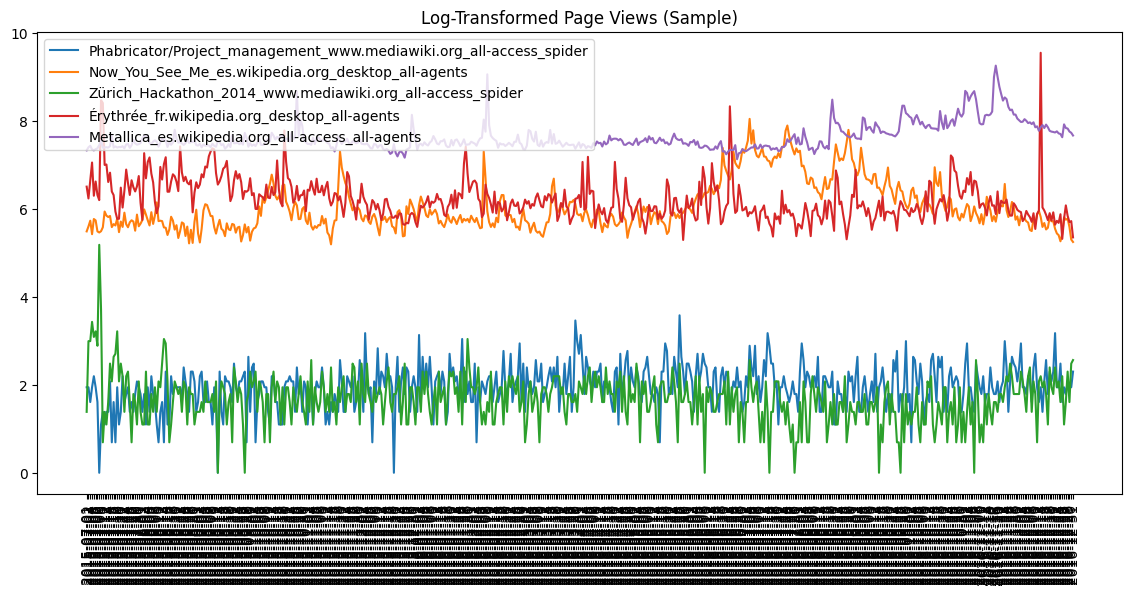

In [9]:
plt.figure(figsize=(14, 6))

for i in range(5):
    row = df_log.iloc[i]
    plt.plot(date_cols, row[date_cols], label=row["Page"])

plt.xticks(rotation=90)
plt.legend()
plt.title("Log-Transformed Page Views (Sample)")
plt.show()


## Save Cleaned Sampled Data

We save the cleaned + log-transformed dataset for the next notebook feature_engineering.


In [10]:
output_path = "/content/drive/MyDrive/CSC480/Final Project/cleaned_sample.csv"
df_log.to_csv(output_path, index=False)

print("Saved cleaned dataset to:", output_path)


Saved cleaned dataset to: /content/drive/MyDrive/CSC480/Final Project/cleaned_sample.csv
